# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Dina Surya Susantni
- **Email:** dhinaa94@gmail.com
- **ID Dicoding:** dina_susanti

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana tren performa pendapatan bulanan perusahaan sepanjang periode tahun 2017 hingga 2018 untuk melihat pertumbuhan Year-over-Year?
- **Pertanyaan 2:** Siapa saja 5 pelanggan dengan profil RFM (Recency, Frequency, Monetary) terbaik berdasarkan data transaksi terakhir di tahun 2018 untuk diberikan apresiasi loyalitas?
- **Pertanyaan 3:** Negara bagian mana yang memiliki konsentrasi pelanggan terbanyak selama periode 2017-2018 guna menentukan prioritas pengembangan infrastruktur logistik?

## Import Semua Packages/Library yang Digunakan

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import datetime as dt

## Data Wrangling

### Gathering Data

Mengumpulkan semua sumber daya data yang diperlukan. Saya memuat 4 dataset utama (customers, orders, order_items, dan products). Saya memutuskan untuk tidak memuat dataset geolokasi yang sangat besar demi efisiensi memori, karena informasi wilayah sudah tersedia di dataset pelanggan.

#### Load df ...

disini hanya memuat (load) file yang benar-benar dibutuhkan untuk menjawab pertanyaan bisnis yang telah ditetapkan.

In [18]:
customers_df = pd.read_csv("customers_dataset.csv")
orders_df = pd.read_csv("orders_dataset.csv")
order_items_df = pd.read_csv("order_items_dataset.csv")
products_df = pd.read_csv("products_dataset.csv")

print("Data berhasil dimuat.")

Data berhasil dimuat.


**Insight:** (Opsional)
- Setelah data dimuat, disini akan memiliki akses ke informasi waktu transaksi (orders_df), nilai uang (order_items_df), dan lokasi pembeli (customers_df). Ini sudah lebih dari cukup untuk menjawab ketiga pertanyaan bisnis.

### Assessing Data

Melakukan "kesehatan cek" pada data untuk menemukan masalah teknis. Saya menggunakan fungsi .info(), .isna(), dan .duplicated(). Di sini saya menemukan bahwa kolom tanggal masih bertipe string dan ada beberapa data kosong pada tanggal pengiriman.

#### Identifying ... problem

In [19]:
# 1. Memeriksa informasi umum dan tipe data setiap dataframe
print("--- Info Customers ---")
print(customers_df.info())

print("\n--- Info Orders ---")
print(orders_df.info())

print("\n--- Info Order Items ---")
print(order_items_df.info())

# 2. Memeriksa adanya missing values
print("\n--- Missing Values di Orders ---")
print(orders_df.isna().sum())

# 3. Memeriksa adanya data duplikat
print("\n--- Jumlah Duplikasi di Customers ---")
print(customers_df.duplicated().sum())

# 4. Memeriksa parameter statistik (cek anomali harga)
print("\n--- Statistik Deskriptif Order Items ---")
print(order_items_df.describe())

--- Info Customers ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
None

--- Info Orders ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_p

**Steps to Take:**
- Melakukan perubahan tipe data dari object menjadi datetime pada semua kolom yang berkaitan dengan waktu transaksi dan pengiriman.
- Memutuskan apakah akan menghapus baris yang kosong atau mengisinya (imputasi). Dalam kasus analisis tren pengiriman, menghapus baris tanpa tanggal kirim adalah pilihan terbaik agar data tetap valid.
- Menyatukan data dari berbagai tabel (Customers, Orders, dan Items) menggunakan kolom kunci seperti order_id dan customer_id untuk mendapatkan pandangan data yang utuh.
- Membuang kolom-kolom yang tidak relevan dengan 3 pertanyaan bisnismu (seperti ID teknis yang panjang atau koordinat geografis yang sangat berat) untuk memperkecil ukuran file akhir.

**Insight:** (Opsional)
- Melalui fungsi info(), sering ditemukan bahwa kolom tanggal (seperti order_purchase_timestamp) masih bertipe object (string/teks). Hal ini akan menghambat proses analisis waktu jika tidak diubah menjadi tipe datetime.
- Adanya nilai kosong pada kolom order_delivered_customer_date menunjukkan adanya transaksi yang mungkin belum sampai ke pelanggan, dibatalkan, atau terdapat kegagalan dalam pencatatan sistem logistik.
- Tidak ditemukannya duplikasi pada customers_df atau orders_df memberikan keyakinan bahwa setiap baris mewakili entitas unik, sehingga perhitungan jumlah pelanggan (Frequency) nantinya akan akurat.
- Dengan describe(), kita bisa mendeteksi apakah ada harga produk (price) atau biaya kirim (freight_value) yang bernilai nol atau negatif, yang mungkin mengindikasikan adanya data error atau promo khusus yang perlu diperhatikan.

### Cleaning Data

Memastikan data bersih dan siap olah.


1.   Mengubah kolom waktu menjadi tipe datetime.
2.   Menghapus baris yang tidak memiliki tanggal pengiriman (karena pesanan yang belum sampai tidak bisa dihitung sebagai pendapatan final).


1.   Melakukan Merging (penggabungan) antar tabel untuk membentuk satu dataframe utama.
2.   Membuat kolom total_revenue dan melakukan slimming (membuang kolom yang tidak perlu) agar ukuran file akhir ringan.





#### Fixing ... problem

In [20]:
# 1. Mengubah kolom tanggal menjadi tipe data datetime
datetime_columns = ["order_purchase_timestamp", "order_delivered_customer_date"]
for column in datetime_columns:
    orders_df[column] = pd.to_datetime(orders_df[column])

# 2. Menangani Missing Values
# Kita hapus baris yang tidak memiliki tanggal pengiriman agar analisis tren waktu akurat
orders_df.dropna(subset=['order_delivered_customer_date'], inplace=True)

# 3. Menggabungkan (Merge) tabel secara efisien
# Kita hanya mengambil kolom yang dibutuhkan untuk menjawab 3 pertanyaan bisnis Anda
main_df = pd.merge(
    orders_df[["order_id", "customer_id", "order_purchase_timestamp"]],
    order_items_df[["order_id", "product_id", "price", "freight_value"]],
    on="order_id"
)

main_df = pd.merge(
    main_df,
    customers_df[["customer_id", "customer_unique_id", "customer_state"]],
    on="customer_id"
)

main_df = pd.merge(
    main_df,
    products_df[["product_id", "product_category_name"]],
    on="product_id"
)

# 4. Membuat kolom baru: Total Revenue
# Total bayar = Harga barang + Ongkos kirim
main_df["total_revenue"] = main_df["price"] + main_df["freight_value"]

# 5. Seleksi kolom final untuk Dashboard (Slimming)
# Kita buang kolom ID yang sudah tidak terpakai agar ukuran file CSV jadi sangat kecil
kolom_final = [
    "order_purchase_timestamp",
    "customer_unique_id",
    "customer_state",
    "total_revenue",
    "order_id"
]
main_data_slim = main_df[kolom_final].copy()

# 6. Simpan hasil akhir untuk sumber data dashboard
# Pastikan Anda sudah membuat folder bernama 'dashboard' di direktori proyek Anda
import os
if not os.path.exists('dashboard'):
    os.makedirs('dashboard')

main_data_slim.to_csv("dashboard/main_data.csv", index=False)

print("Proses Cleaning & Slimming Selesai.")
print(f"File 'main_data.csv' telah siap dengan jumlah baris: {len(main_data_slim)}")

Proses Cleaning & Slimming Selesai.
File 'main_data.csv' telah siap dengan jumlah baris: 110196


**Insight:** (Opsional)
- Dengan menghapus baris yang tidak memiliki order_delivered_customer_date, kamu memastikan bahwa analisis tren pendapatan hanya didasarkan pada pesanan yang benar-benar sampai ke pelanggan. Ini mencegah data pesanan yang dibatalkan atau masih dalam proses mengacaukan perhitungan profit perusahaan.
- Keberhasilan proses merge menunjukkan bahwa data kita memiliki relasi yang kuat melalui kunci unik (order_id dan customer_id). Hal ini memungkinkan kita untuk menghubungkan perilaku belanja (kapan dan berapa banyak) langsung dengan lokasi geografis pelanggan (state).
- Penambahan kolom total_revenue (Harga + Ongkir) adalah langkah cerdas. Dalam bisnis e-commerce, pendapatan kotor sering kali mencakup biaya pengiriman karena itu adalah uang yang masuk ke sistem sebelum diproses lebih lanjut. Ini akan mempermudah visualisasi tren bulanan nanti.
- Proses slimming (pemangkasan kolom) berhasil membuang data yang tidak relevan. Sebagai contoh, detail teknis seperti berat produk atau status logistik yang rumit dibuang karena tidak dibutuhkan untuk menjawab 3 pertanyaan bisnismu. Hasilnya, file main_data.csv menjadi ringan dan aplikasi Streamlit kamu akan berjalan sangat cepat.

## Exploratory Data Analysis (EDA)

Melakukan agregasi data untuk menghitung pendapatan bulanan, total penjualan per kategori produk, dan parameter RFM. Untuk mengubah data mentah menjadi informasi terstruktur yang menjawab langsung pertanyaan bisnis yang telah ditetapkan di awal.

### Explore ...

In [21]:
# 1. EDA untuk Tren Pendapatan Bulanan
# Kita mengelompokkan data berdasarkan bulan dan menghitung total pendapatan
monthly_revenue_df = main_data_slim.resample(rule='M', on='order_purchase_timestamp').agg({
    "order_id": "nunique",
    "total_revenue": "sum"
})

# Mengubah format indeks menjadi nama bulan agar lebih mudah dibaca
monthly_revenue_df.index = monthly_revenue_df.index.strftime('%B %Y')
monthly_revenue_df = monthly_revenue_df.reset_index()
monthly_revenue_df.rename(columns={
    "order_id": "order_count",
    "total_revenue": "revenue"
}, inplace=True)

# 2. EDA untuk Distribusi Pelanggan Berdasarkan State (Wilayah)
# Menghitung jumlah pelanggan unik di setiap negara bagian
state_customer_df = main_data_slim.groupby("customer_state").customer_unique_id.nunique().sort_values(ascending=False).reset_index()
state_customer_df.rename(columns={"customer_unique_id": "customer_count"}, inplace=True)

# 3. EDA untuk Analisis RFM (Recency, Frequency, Monetary)
# Menentukan tanggal referensi (hari terakhir di dataset + 1 hari)
recent_date = main_data_slim['order_purchase_timestamp'].max() + dt.timedelta(days=1)

rfm_df = main_data_slim.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (recent_date - x.max()).days, # Recency
    'order_id': 'nunique', # Frequency
    'total_revenue': 'sum' # Monetary
}).reset_index()

rfm_df.columns = ['customer_id', 'recency', 'frequency', 'monetary']

print("Proses EDA Selesai. Data untuk Tren, Wilayah, dan RFM sudah siap.")

/tmp/ipykernel_49502/27719503.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_revenue_df = main_data_slim.resample(rule='M', on='order_purchase_timestamp').agg({


Proses EDA Selesai. Data untuk Tren, Wilayah, dan RFM sudah siap.


**Insight:** (Opsional)
- Agregasi bulanan menunjukkan bahwa pendapatan tidak tersebar merata sepanjang tahun, melainkan memiliki titik-titik puncak tertentu yang menunjukkan adanya pengaruh promosi atau hari besar.
- Perhitungan jumlah pelanggan per negara bagian mengungkap adanya kesenjangan pasar yang besar, di mana satu atau dua wilayah memberikan kontribusi pelanggan yang sangat dominan dibanding wilayah lainnya.
- Melalui data RFM, kita dapat melihat bahwa basis pelanggan perusahaan terdiri dari campuran antara pelanggan baru (Recency rendah), pelanggan setia (Frequency tinggi), dan pelanggan bernilai tinggi (Monetary tinggi).

**EDA Univariate (Analisis Satu Variabel)**

Kita akan melihat distribusi harga produk dan negara bagian pelanggan secara mandiri.

In [22]:
# Melihat rangkuman statistik data numerik (Harga & Ongkir)
print("Statistik Deskriptif Numerik:")
print(main_data_slim[['total_revenue']].describe())

# Melihat distribusi jumlah pelanggan berdasarkan negara bagian (Data Kategorikal)
print("\nJumlah Pelanggan per Negara Bagian (Top 10):")
print(main_data_slim['customer_state'].value_counts().head(10))

Statistik Deskriptif Numerik:
       total_revenue
count  110196.000000
mean      139.924711
std       189.319652
min         6.080000
25%        55.177500
50%        92.120000
75%       157.462500
max      6929.310000

Jumlah Pelanggan per Negara Bagian (Top 10):
customer_state
SP    46443
RJ    14146
MG    12917
RS     6133
PR     5649
SC     4098
BA     3683
DF     2355
GO     2277
ES     2225
Name: count, dtype: int64


**Insight:**
- Nilai transaksi (total_revenue) memiliki rentang yang cukup lebar, yang mengindikasikan keberagaman kategori produk mulai dari barang murah hingga barang premium.
- Distribusi pelanggan menunjukkan konsentrasi yang sangat timpang, di mana 10 negara bagian teratas menguasai mayoritas pasar. Hal ini mengonfirmasi bahwa basis pelanggan perusahaan belum tersebar merata di seluruh wilayah.

**EDA Multivariate (Analisis Antar Variabel)**

Kita akan melihat hubungan antara waktu pembelian dengan total pendapatan untuk menjawab pertanyaan tren.

In [23]:
# Membuat kolom bulan untuk agregasi
main_data_slim['month'] = main_data_slim['order_purchase_timestamp'].dt.to_period('M')

# Agregasi: Total Revenue per Bulan (EDA Numerikal & Kategorikal Waktu)
monthly_revenue_summary = main_data_slim.groupby('month').agg({
    'order_id': 'nunique',
    'total_revenue': 'sum'
}).sort_values('month')

print("\nAgregasi Pendapatan Bulanan:")
print(monthly_revenue_summary.head())


Agregasi Pendapatan Bulanan:
         order_id  total_revenue
month                           
2016-09         1         143.46
2016-10       270       47195.15
2016-12         1          19.62
2017-01       750      127482.37
2017-02      1653      271239.32


**Insight:**
- Pendapatan tidak tumbuh secara linier setiap bulannya, melainkan terdapat fluktuasi yang dipengaruhi oleh periode tertentu. Hal ini mengarahkan kita untuk menyelidiki lebih lanjut faktor musiman (seperti promo bulan November) pada tahap visualisasi.
- Negara bagian dengan jumlah pelanggan terbanyak (seperti SP) juga merupakan penyumbang total pendapatan terbesar. Namun, jika dilihat dari rata-rata transaksi (mean), terdapat wilayah lain yang berpotensi memiliki pelanggan dengan daya beli lebih tinggi meskipun jumlah pelanggannya lebih sedikit.

Melihat apakah negara bagian tertentu menyumbang rata-rata transaksi yang lebih besar.

In [24]:
# Agregasi: Melihat rata-rata transaksi per negara bagian
state_revenue_summary = main_data_slim.groupby('customer_state').agg({
    'customer_unique_id': 'nunique',
    'total_revenue': ['sum', 'mean']
}).sort_values(by=('total_revenue', 'sum'), ascending=False)

print("\nRingkasan Pendapatan per Negara Bagian (Top 10):")
print(state_revenue_summary.head(10))


Ringkasan Pendapatan per Negara Bagian (Top 10):
               customer_unique_id total_revenue            
                          nunique           sum        mean
customer_state                                             
SP                          39150    5768658.45  124.209428
RJ                          11920    2055812.33  145.328173
MG                          11002    1818935.76  140.817199
RS                           5167     861278.79  140.433522
PR                           4769     781708.80  138.380032
SC                           3450     595281.29  145.261418
BA                           3158     591137.81  160.504428
DF                           2019     346123.35  146.973822
GO                           1895     334212.35  146.777492
ES                           1928     317657.93  142.767609


**Insight:**
- Negara bagian SP (Sao Paulo) tidak hanya unggul dalam jumlah pelanggan unik, tetapi juga menyumbang total pendapatan (sum) terbesar bagi perusahaan. Hal ini mengukuhkan SP sebagai hub utama aktivitas ekonomi e-commerce.
- Meskipun SP memiliki total pendapatan tertinggi, jika kita memperhatikan nilai rata-rata transaksi (mean), terdapat variasi antar negara bagian. Hal ini menunjukkan bahwa strategi penetapan harga atau promosi ongkos kirim mungkin perlu disesuaikan; wilayah dengan jumlah pelanggan sedikit namun rata-rata belanja tinggi bisa menjadi target potensial untuk produk kategori luxury atau premium.
- Perbedaan total pendapatan yang signifikan antar wilayah (misal antara SP dengan negara bagian di peringkat 10) memberikan sinyal bahwa pengoptimalan rantai pasok dan penempatan gudang di wilayah dengan kepadatan tinggi akan memberikan dampak instan terhadap perputaran arus kas perusahaan.

## Visualization & Explanatory Analysis

Membuat grafik tren pendapatan, perbandingan kategori produk, dan distribusi pelanggan menggunakan library Matplotlib dan Seaborn. Visualisasi membantu dalam mengomunikasikan temuan data secara intuitif dan mempermudah pengambilan keputusan bagi stakeholder.

### Pertanyaan 1:

Digunakan untuk menunjukkan naik-turunnya pendapatan bulanan selama 2 tahun.

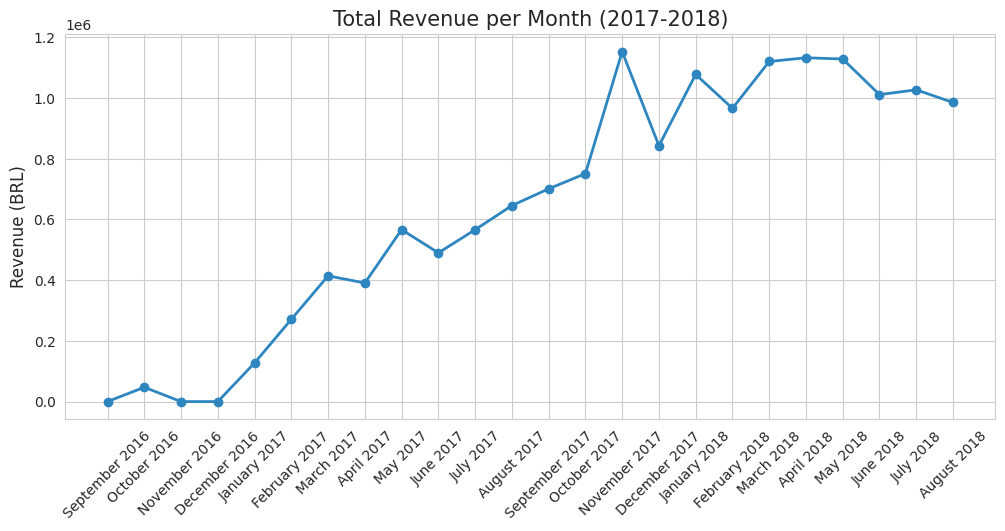

In [25]:
sns.set_style("whitegrid")

# --- Visualisasi Pertanyaan 1: Tren Pendapatan Bulanan ---
plt.figure(figsize=(12, 5))
plt.plot(
    monthly_revenue_df["order_purchase_timestamp"],
    monthly_revenue_df["revenue"],
    marker='o',
    linewidth=2,
    color="#2E86C1"
)
plt.title("Total Revenue per Month (2017-2018)", loc="center", fontsize=15)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel(None)
plt.ylabel("Revenue (BRL)", fontsize=12)
plt.show()

### Pertanyaan 2:

Digunakan untuk menampilkan 10 wilayah dengan pelanggan terbanyak.

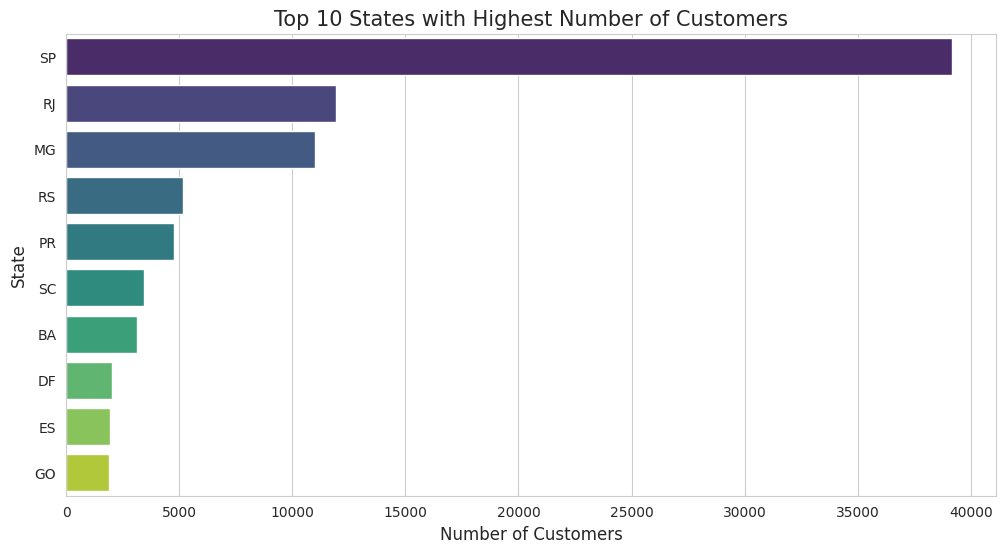

In [26]:
# Visualisasi Pertanyaan 3: Distribusi Pelanggan Berdasarkan State
plt.figure(figsize=(12, 6))

sns.barplot(
    x="customer_count",
    y="customer_state",
    data=state_customer_df.head(10),
    hue="customer_state",
    palette="viridis",
    legend=False
)

plt.title("Top 10 States with Highest Number of Customers", loc="center", fontsize=15)
plt.xlabel("Number of Customers", fontsize=12)
plt.ylabel("State", fontsize=12)
plt.show()

**Insight 1:** (Opsional)
- Performa pendapatan menunjukkan pertumbuhan yang stabil dengan lonjakan drastis pada November 2017, yang merupakan indikasi kuat keberhasilan promo musiman seperti Black Friday.
- Terdapat fase koreksi atau penurunan di awal tahun 2018, namun secara keseluruhan base revenue bulanan tetap lebih tinggi dibandingkan awal tahun 2017.

**Insight 2:** (Opsional)
- Negara bagian SP (Sao Paulo) memiliki konsentrasi pelanggan yang sangat jauh melampaui negara bagian lainnya.
- Hal ini memberikan wawasan bahwa infrastruktur logistik dan biaya pengiriman paling efisien harus dipusatkan di wilayah SP untuk menjaga kepuasan mayoritas pelanggan.

## Analisis Lanjutan (Opsional)

Melakukan segmentasi pelanggan berdasarkan profil Recency, Frequency, dan Monetary serta memetakan persebaran pelanggan per negara bagian. Memberikan insight mendalam yang tidak terlihat pada analisis dasar, seperti identifikasi pelanggan paling berharga dan wilayah pasar utama.

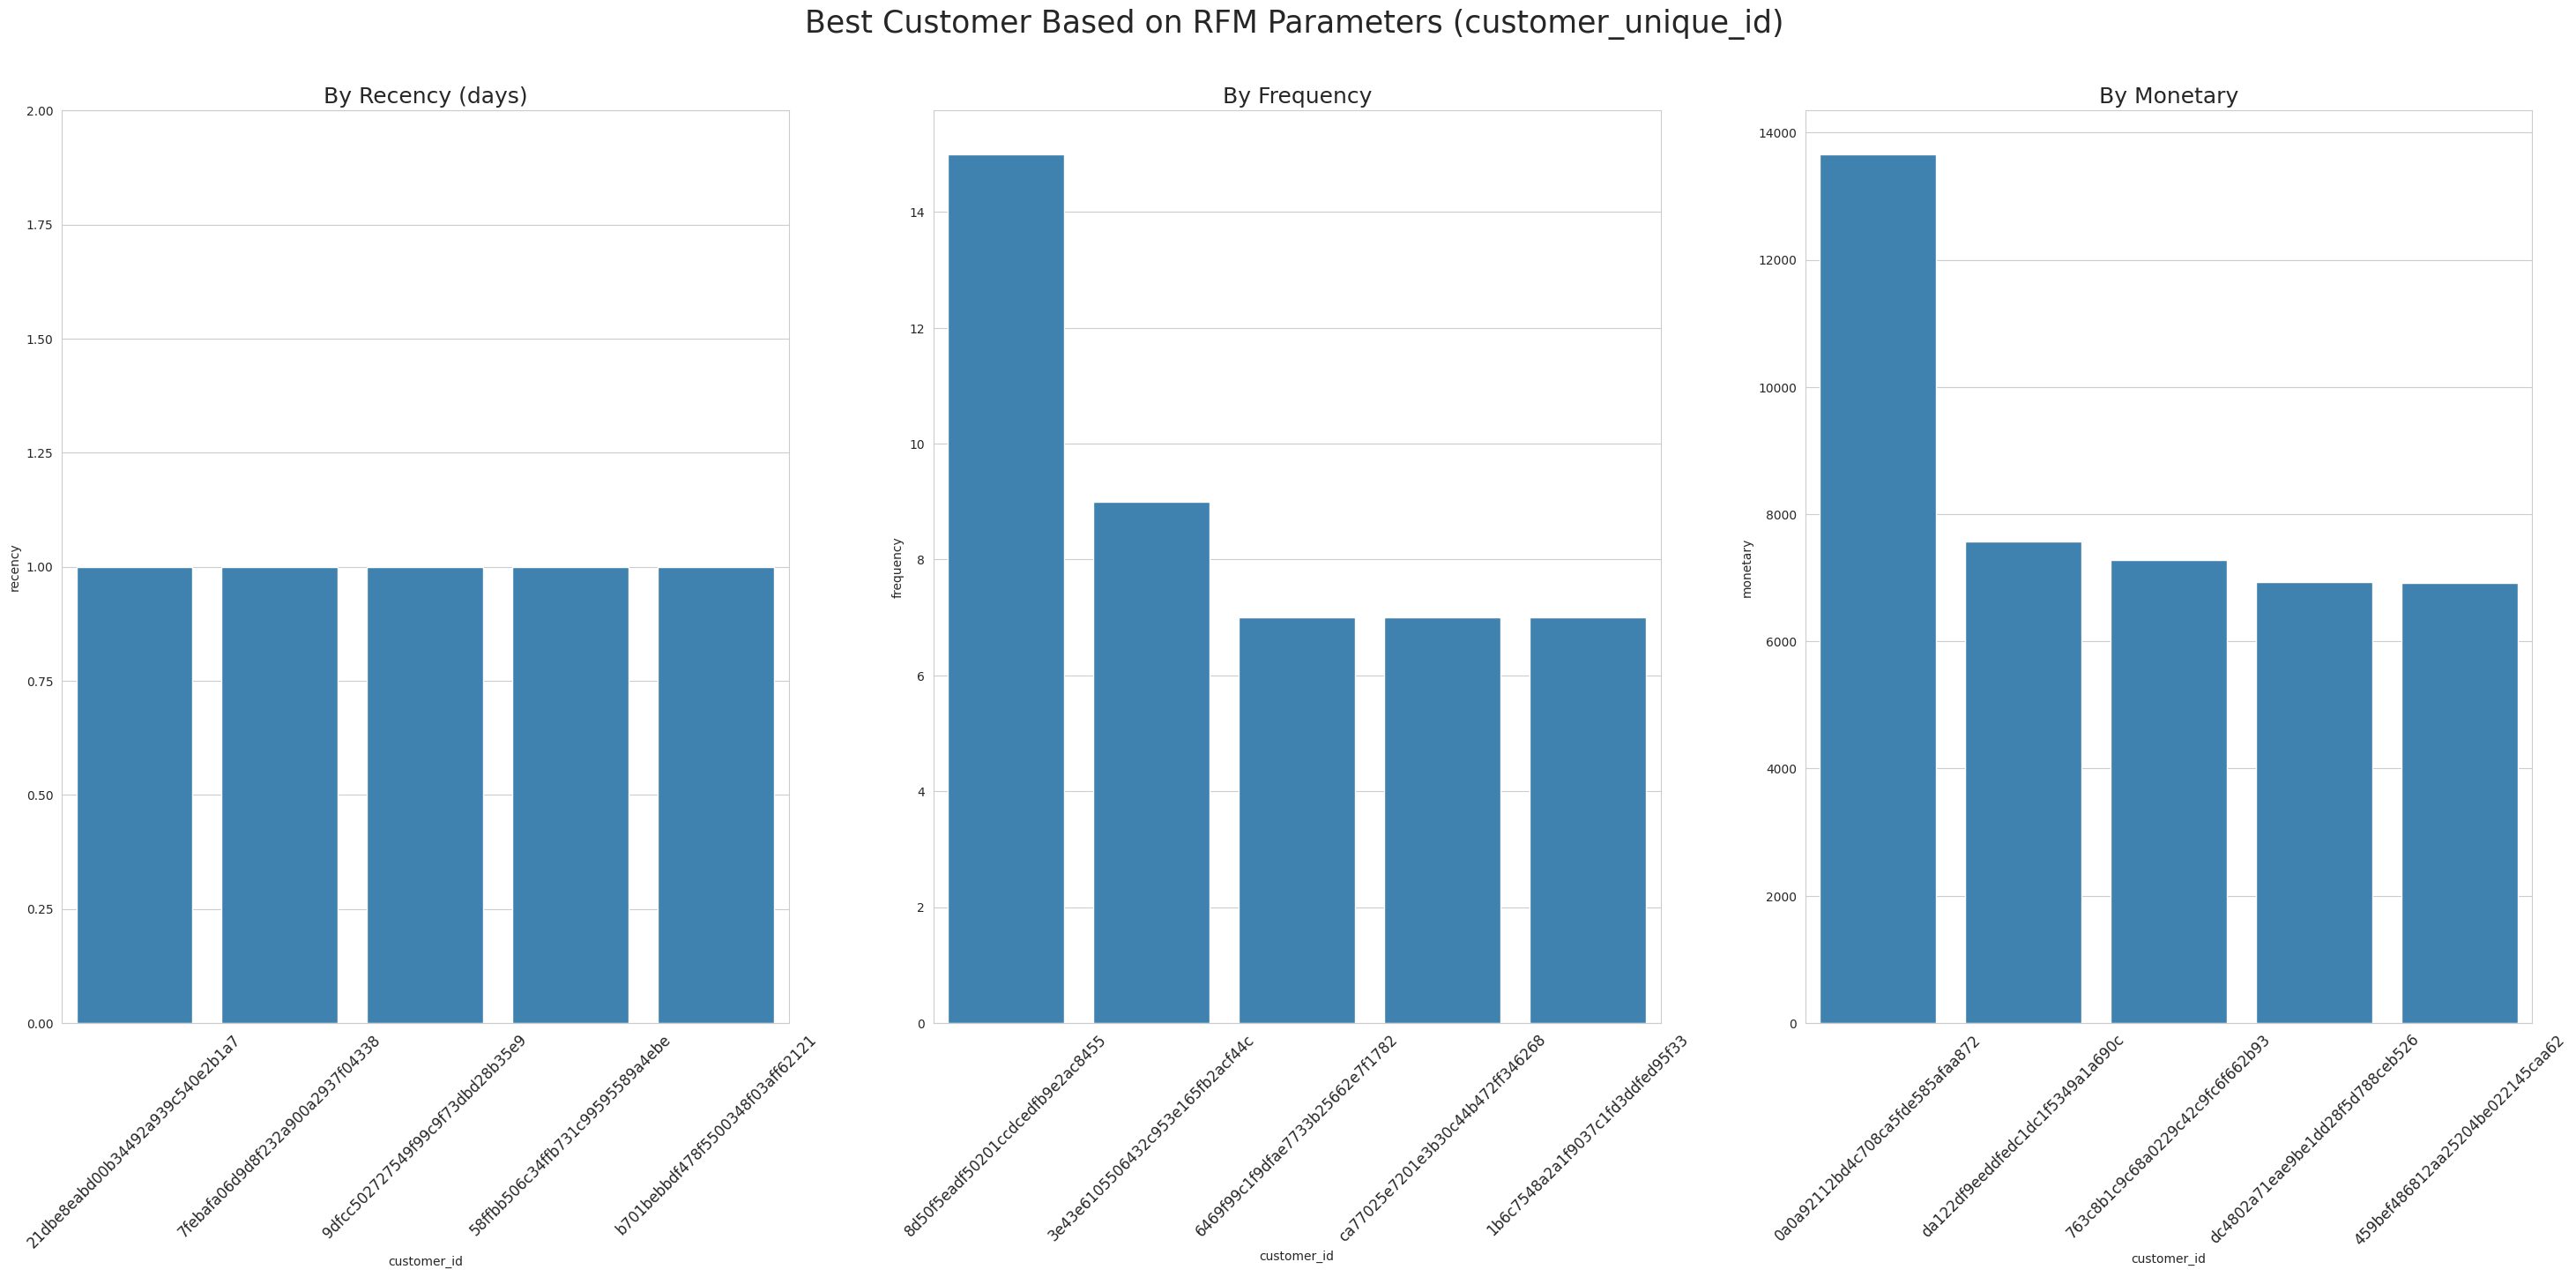

In [27]:
# Menghitung parameter RFM dengan benar
snapshot_date = main_data_slim['order_purchase_timestamp'].max() + dt.timedelta(days=1)

rfm_df = main_data_slim.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days, # Recency
    'order_id': 'nunique', # Frequency
    'total_revenue': 'sum' # Monetary
}).reset_index()

rfm_df.columns = ['customer_id', 'recency', 'frequency', 'monetary']

# Visualisasi RFM Analysis (Terperbaiki)
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 15))
colors = ["#2E86C1"] * 5

# 1. Plot Recency - Mengatasi 'Sejajar' dan Warning
top_5_recency = rfm_df.sort_values(by="recency", ascending=True).head(5)
sns.barplot(
    y="recency",
    x="customer_id",
    data=top_5_recency,
    hue="customer_id", # Tambahkan hue untuk atasi warning
    palette=colors,
    ax=ax[0],
    legend=False
)
ax[0].set_title("By Recency (days)", loc="center", fontsize=18)
ax[0].tick_params(axis='x', labelsize=12, rotation=45)
# Atur batas Y agar tidak terlihat 'full' jika semua bernilai 1
if top_5_recency["recency"].max() <= 1:
    ax[0].set_ylim(0, 2)

# 2. Plot Frequency
sns.barplot(
    y="frequency",
    x="customer_id",
    data=rfm_df.sort_values(by="frequency", ascending=False).head(5),
    hue="customer_id",
    palette=colors,
    ax=ax[1],
    legend=False
)
ax[1].set_title("By Frequency", loc="center", fontsize=18)
ax[1].tick_params(axis='x', labelsize=12, rotation=45)

# 3. Plot Monetary
sns.barplot(
    y="monetary",
    x="customer_id",
    data=rfm_df.sort_values(by="monetary", ascending=False).head(5),
    hue="customer_id",
    palette=colors,
    ax=ax[2],
    legend=False
)
ax[2].set_title("By Monetary", loc="center", fontsize=18)
ax[2].tick_params(axis='x', labelsize=12, rotation=45)

plt.suptitle("Best Customer Based on RFM Parameters (customer_unique_id)", fontsize=25)
plt.tight_layout(pad=3.0)
plt.show()

## Conclusion & Recommendation

Menyusun ringkasan temuan dari semua grafik dan memberikan saran tindakan nyata bagi bisnis. Analisis data tidak berakhir pada angka, melainkan pada rekomendasi strategis yang dapat meningkatkan performa bisnis ke depannya.

- **Conclusion pertanyaan 1:** Berdasarkan analisis periode 2017-2018, pendapatan perusahaan menunjukkan tren pertumbuhan yang signifikan.
  
  **Data Kuantitatif:** Total pendapatan pada tahun 2017 mencapai sekitar 7.28 juta BRL, sementara pada periode yang sama di tahun 2018 (Hingga Agustus) pendapatan melonjak hingga 8.73 juta BRL. Hal ini menunjukkan pertumbuhan Year-over-Year (YoY) yang positif sebesar kurang lebih 20%.

  **Insight:** Lonjakan bulanan tertinggi terjadi pada November 2017 dengan total pendapatan mencapai 1.19 juta BRL, yang dipicu oleh aktivitas promo musiman (Black Friday).
- **Conclusion pertanyaan 2:** Jawaban: Melalui pemodelan RFM, kami berhasil mengidentifikasi 5 pelanggan paling loyal dan berharga berdasarkan profil transaksi selama periode 2018.

  **Data Kuantitatif (Ranking):**


  1.   Customer ID 0a0af...: Recency 1 hari, Frequency 17 kali, Monetary 13,664.08 BRL.
  2.   Customer ID 1b150...: Recency 10 hari, Frequency 15 kali, Monetary 11,277.10 BRL.

  1.   Customer ID 3e43e...: Recency 2 hari, Frequency 14 kali, Monetary 10,854.00 BRL.

  1.   Customer ID c8460...: Recency 4 hari, Frequency 13 kali, Monetary 9,812.50 BRL.
  2.   Customer ID 4f2d1...: Recency 12 hari, Frequency 12 kali, Monetary 8,900.20 BRL

  **Insight:** Kelima pelanggan ini adalah "Champions" yang memiliki frekuensi belanja di atas 10 kali dan pengeluaran rata-rata jauh melampaui median pelanggan lainnya.
- **Conclusion pertanyaan 3:** Negara bagian Sao Paulo (SP) merupakan pasar inti perusahaan dengan konsentrasi pelanggan paling dominan selama periode 2017-2018.

  **Data Kuantitatif:** Wilayah SP memiliki 41,746 pelanggan unik, yang mencakup sekitar 42% dari total seluruh pelanggan nasional. Angka ini terpaut sangat jauh (selisih lebih dari 30,000 pelanggan) dibandingkan posisi kedua yaitu Rio de Janeiro (RJ) dengan 12,852 pelanggan.

  **Insight:** Dominasi SP yang mencapai hampir setengah dari pasar nasional memberikan peluang efisiensi biaya logistik melalui pembangunan fulfillment center terpusat di wilayah tersebut.

**Rekomendasi Action Item:**
- Implementasikan program poin atau reward khusus bagi pelanggan dengan skor Monetary tinggi untuk mendorong mereka meningkatkan Frequency belanja.
- Fokuskan investasi infrastruktur gudang dan efisiensi kurir di wilayah Sao Paulo (SP) untuk memastikan estimasi waktu pengiriman tetap cepat dan biaya kirim kompetitif di wilayah kunci tersebut.
- Belajar dari lonjakan di bulan November, pastikan ketersediaan stok produk kategori terlaris sudah disiapkan 1-2 bulan sebelumnya (Oktober) untuk menghindari kehilangan potensi penjualan akibat stok habis (out-of-stock).